# Bayesian regression forest plots

Combined plotting notebook for publication-style forest plots from the saved Bayesian socio-geographic regression summaries. Each model section checks whether its fitted `summary.csv` files are available before plotting, so the notebook can be rerun as additional model fits finish.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "utils").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "utils").exists():
    raise RuntimeError("Run this notebook from inside the scotland repository.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    
from sse_detection.lib import (  # noqa: E402
    plot_composition_primary_expanded_forest,
    plot_mixing_primary_expanded_forest,
)

RESULT_DIR = PROJECT_ROOT / "sse_detection/results/bayesian_outputs"
LOGISTIC_RESULT_DIR = RESULT_DIR / "logistic"
LINEAR_RESULT_DIR = RESULT_DIR / "linear"
FIGURE_DIR = RESULT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
def has_summaries(base_dir: Path, relative_dirs: list[str]) -> bool:
    """Return True when every requested model summary exists."""
    return all((base_dir / rel / "summary.csv").exists() for rel in relative_dirs)


def save_forest(fig, stem: str) -> tuple[Path, Path]:
    """Save a forest plot as PDF and high-resolution PNG."""
    pdf_path = FIGURE_DIR / f"{stem}.pdf"
    png_path = FIGURE_DIR / f"{stem}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=600, bbox_inches="tight")
    return pdf_path, png_path


plot_outputs = {}

## Logistic candidate models


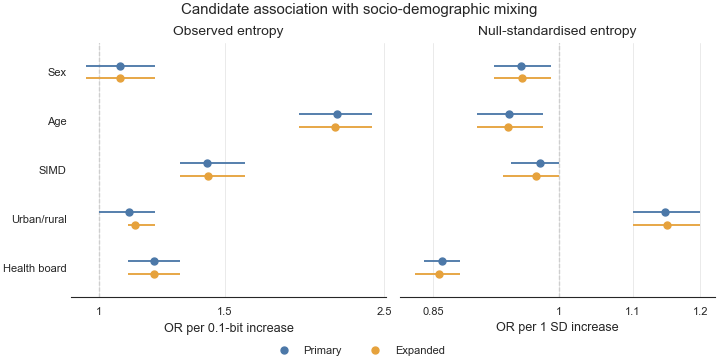

,scale,model_kind,model_set,feature,parameter,mean,hdi95_lb,hdi95_ub,OR_mean,OR_hdi95_lb,OR_hdi95_ub,P(OR > 1 | data),P(OR < 1 | data),summary_path,row_id
0,observed,primary,observed_primary,sex_entropy,sex_entropy_obs_x10,0.0668,-0.040,0.1800,1.0710,0.96,1.20,0.886375,0.113625,/Users/ydnkka/Desktop/PhD Project/projects/sco...,sex_entropy
5,observed,expanded,observed_expanded,sex_entropy,sex_entropy_obs_x10,0.0680,-0.039,0.1900,1.0730,0.96,1.20,0.887250,0.112750,/Users/ydnkka/Desktop/PhD Project/projects/sco...,sex_entropy
1,observed,primary,observed_primary,age_entropy,age_entropy_obs_x10,0.7620,0.660,0.8700,2.1450,1.90,2.40,1.000000,0.000000,/Users/ydnkka/Desktop/PhD Project/projects/sco...,age_entropy
6,observed,expanded,observed_expanded,age_entropy,age_entropy_obs_x10,0.7570,0.650,0.8700,2.1340,1.90,2.40,1.000000,0.000000,/Users/ydnkka/Desktop/PhD Project/projects/sco...,age_entropy
2,observed,primary,observed_primary,simd_entropy,simd_entropy_obs_x10,0.3480,0.240,0.4600,1.4180,1.30,1.60,1.000000,0.000000,/Users/ydnkka/Desktop/PhD Project/projects/sco...,simd_entropy
7,observed,expanded,observed_expanded,simd_entropy,simd_entropy_obs_x10,0.3490,0.240,0.4700,1.4210,1.30,1.60,1.000000,0.000000,/Users/ydnkka/Desktop/PhD Project/projects/sco...,simd_entropy
3,observed,primary,observed_primary,urban_rural_entropy,urban_rural_entropy_obs_x10,0.0984,0.031,0.1700,1.1040,1.00,1.20,0.997375,0.002625,/Users/ydnkka/Desktop/PhD Project/projects/sco...,urban_rural_entropy
8,observed,expanded,observed_expanded,urban_rural_entropy,urban_rural_entropy_obs_x10,0.1175,0.050,0.1900,1.1253,1.10,1.20,0.999125,0.000875,/Users/ydnkka/Desktop/PhD Project/projects/sco...,urban_rural_entropy
4,observed,primary,observed_primary,health_board_entropy,health_board_entropy_obs_x10,0.1778,0.120,0.2400,1.1952,1.10,1.30,1.000000,0.000000,/Users/ydnkka/Desktop/PhD Project/projects/sco...,health_board_entropy
9,observed,expanded,observed_expanded,health_board_entropy,health_board_entropy_obs_x10,0.1777,0.120,0.2400,1.1951,1.10,1.30,1.000000,0.000000,/Users/ydnkka/Desktop/PhD Project/projects/sco...,health_board_entropy


In [3]:
required = [
    "mixing/observed_primary",
    "mixing/observed_expanded",
    "mixing/null_primary",
    "mixing/null_expanded",
]

if has_summaries(LOGISTIC_RESULT_DIR, required):
    logistic_mixing = plot_mixing_primary_expanded_forest(
        LOGISTIC_RESULT_DIR,
        family="logistic",
        title="Candidate association with socio-demographic mixing",
    )
    plot_outputs["logistic_mixing"] = {
        "result": logistic_mixing,
        "files": save_forest(
            logistic_mixing.fig,
            "logistic_mixing_primary_expanded_forest",
        ),
    }
    display(logistic_mixing.fig)
    display(logistic_mixing.plot_data)
else:
    missing = [
        rel
        for rel in required
        if not (LOGISTIC_RESULT_DIR / rel / "summary.csv").exists()
    ]
    print("Skipping logistic mixing forest; missing summaries:")
    print("\n".join(str(LOGISTIC_RESULT_DIR / rel / "summary.csv") for rel in missing))

In [4]:
required = ["composition/primary", "composition/expanded"]

if has_summaries(LOGISTIC_RESULT_DIR, required):
    logistic_composition = plot_composition_primary_expanded_forest(
        LOGISTIC_RESULT_DIR,
        family="logistic",
        title="Candidate association with sequence composition",
    )
    plot_outputs["logistic_composition"] = {
        "result": logistic_composition,
        "files": save_forest(
            logistic_composition.fig,
            "logistic_composition_primary_expanded_forest",
        ),
    }
    display(logistic_composition.fig)
    display(logistic_composition.plot_data)
else:
    missing = [
        rel
        for rel in required
        if not (LOGISTIC_RESULT_DIR / rel / "summary.csv").exists()
    ]
    print("Skipping logistic composition forest; missing summaries:")
    print("\n".join(str(LOGISTIC_RESULT_DIR / rel / "summary.csv") for rel in missing))

Skipping logistic composition forest; missing summaries:
/Users/ydnkka/Desktop/PhD Project/projects/scotland/sse_detection/results/bayesian_outputs/logistic/composition/expanded/summary.csv


## Linear score models


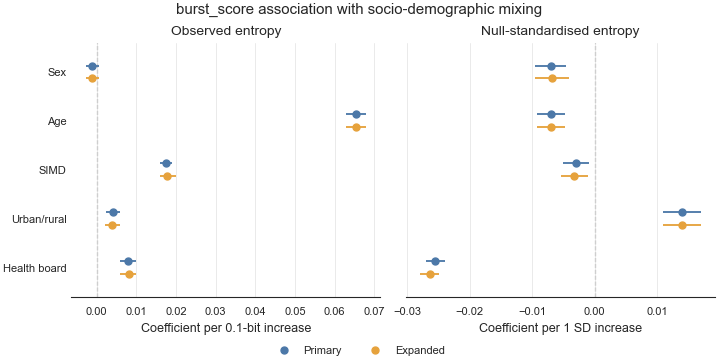

,scale,model_kind,model_set,feature,parameter,mean,hdi95_lb,hdi95_ub,P(beta > 0 | data),P(beta < 0 | data),summary_path,row_id
0,observed,primary,observed_primary,sex_entropy,sex_entropy_obs_x10,-0.00105,-0.0027,0.00062,0.104750,0.895250,/Users/ydnkka/Desktop/PhD Project/projects/sco...,sex_entropy
5,observed,expanded,observed_expanded,sex_entropy,sex_entropy_obs_x10,-0.00107,-0.0028,0.00064,0.103125,0.896875,/Users/ydnkka/Desktop/PhD Project/projects/sco...,sex_entropy
1,observed,primary,observed_primary,age_entropy,age_entropy_obs_x10,0.06550,0.0630,0.06800,1.000000,0.000000,/Users/ydnkka/Desktop/PhD Project/projects/sco...,age_entropy
6,observed,expanded,observed_expanded,age_entropy,age_entropy_obs_x10,0.06542,0.0630,0.06800,1.000000,0.000000,/Users/ydnkka/Desktop/PhD Project/projects/sco...,age_entropy
2,observed,primary,observed_primary,simd_entropy,simd_entropy_obs_x10,0.01748,0.0160,0.01900,1.000000,0.000000,/Users/ydnkka/Desktop/PhD Project/projects/sco...,simd_entropy
7,observed,expanded,observed_expanded,simd_entropy,simd_entropy_obs_x10,0.01786,0.0160,0.02000,1.000000,0.000000,/Users/ydnkka/Desktop/PhD Project/projects/sco...,simd_entropy
3,observed,primary,observed_primary,urban_rural_entropy,urban_rural_entropy_obs_x10,0.00406,0.0023,0.00590,1.000000,0.000000,/Users/ydnkka/Desktop/PhD Project/projects/sco...,urban_rural_entropy
8,observed,expanded,observed_expanded,urban_rural_entropy,urban_rural_entropy_obs_x10,0.00394,0.0021,0.00580,1.000000,0.000000,/Users/ydnkka/Desktop/PhD Project/projects/sco...,urban_rural_entropy
4,observed,primary,observed_primary,health_board_entropy,health_board_entropy_obs_x10,0.00787,0.0059,0.00990,1.000000,0.000000,/Users/ydnkka/Desktop/PhD Project/projects/sco...,health_board_entropy
9,observed,expanded,observed_expanded,health_board_entropy,health_board_entropy_obs_x10,0.00805,0.0060,0.01000,1.000000,0.000000,/Users/ydnkka/Desktop/PhD Project/projects/sco...,health_board_entropy


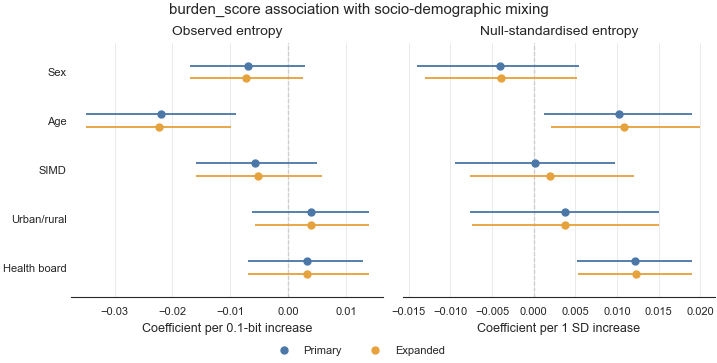

,scale,model_kind,model_set,feature,parameter,mean,hdi95_lb,hdi95_ub,P(beta > 0 | data),P(beta < 0 | data),summary_path,row_id
0,observed,primary,observed_primary,sex_entropy,sex_entropy_obs_x10,-0.00695,-0.0170,0.0030,0.088375,0.911625,/Users/ydnkka/Desktop/PhD Project/projects/sco...,sex_entropy
5,observed,expanded,observed_expanded,sex_entropy,sex_entropy_obs_x10,-0.00720,-0.0170,0.0025,0.074625,0.925375,/Users/ydnkka/Desktop/PhD Project/projects/sco...,sex_entropy
1,observed,primary,observed_primary,age_entropy,age_entropy_obs_x10,-0.02200,-0.0350,-0.0090,0.000750,0.999250,/Users/ydnkka/Desktop/PhD Project/projects/sco...,age_entropy
6,observed,expanded,observed_expanded,age_entropy,age_entropy_obs_x10,-0.02230,-0.0350,-0.0098,0.000250,0.999750,/Users/ydnkka/Desktop/PhD Project/projects/sco...,age_entropy
2,observed,primary,observed_primary,simd_entropy,simd_entropy_obs_x10,-0.00570,-0.0160,0.0050,0.145000,0.855000,/Users/ydnkka/Desktop/PhD Project/projects/sco...,simd_entropy
7,observed,expanded,observed_expanded,simd_entropy,simd_entropy_obs_x10,-0.00520,-0.0160,0.0058,0.169375,0.830625,/Users/ydnkka/Desktop/PhD Project/projects/sco...,simd_entropy
3,observed,primary,observed_primary,urban_rural_entropy,urban_rural_entropy_obs_x10,0.00388,-0.0063,0.0140,0.780500,0.219500,/Users/ydnkka/Desktop/PhD Project/projects/sco...,urban_rural_entropy
8,observed,expanded,observed_expanded,urban_rural_entropy,urban_rural_entropy_obs_x10,0.00400,-0.0058,0.0140,0.785125,0.214875,/Users/ydnkka/Desktop/PhD Project/projects/sco...,urban_rural_entropy
4,observed,primary,observed_primary,health_board_entropy,health_board_entropy_obs_x10,0.00320,-0.0070,0.0130,0.726875,0.273125,/Users/ydnkka/Desktop/PhD Project/projects/sco...,health_board_entropy
9,observed,expanded,observed_expanded,health_board_entropy,health_board_entropy_obs_x10,0.00330,-0.0069,0.0140,0.726375,0.273625,/Users/ydnkka/Desktop/PhD Project/projects/sco...,health_board_entropy


In [5]:
linear_mixing_jobs = {
    "burst_score": [
        "mixing/burst_score/null_primary",
        "mixing/burst_score/null_expanded",
        "mixing/burst_score/observed_primary",
        "mixing/burst_score/observed_expanded",
    ],
    "burden_score": [
        "mixing/burden_score/null_primary",
        "mixing/burden_score/null_expanded",
        "mixing/burden_score/observed_primary",
        "mixing/burden_score/observed_expanded",
    ],
}

for outcome, required in linear_mixing_jobs.items():
    if has_summaries(LINEAR_RESULT_DIR, required):
        linear_mixing = plot_mixing_primary_expanded_forest(
            LINEAR_RESULT_DIR,
            family="linear",
            outcome=outcome,
            title=f"{outcome} association with socio-demographic mixing",
        )
        plot_outputs[f"linear_mixing_{outcome}"] = {
            "result": linear_mixing,
            "files": save_forest(
                linear_mixing.fig,
                f"linear_mixing_{outcome}_primary_expanded_forest",
            ),
        }
        display(linear_mixing.fig)
        display(linear_mixing.plot_data)
    else:
        missing = [
            rel
            for rel in required
            if not (LINEAR_RESULT_DIR / rel / "summary.csv").exists()
        ]
        print(f"Skipping linear mixing forest for {outcome}; missing summaries:")
        print(
            "\n".join(str(LINEAR_RESULT_DIR / rel / "summary.csv") for rel in missing)
        )

Skipping linear composition forest for burst_score; missing summaries:
/Users/ydnkka/Desktop/PhD Project/projects/scotland/sse_detection/results/bayesian_outputs/linear/composition/burst_score/primary/summary.csv
/Users/ydnkka/Desktop/PhD Project/projects/scotland/sse_detection/results/bayesian_outputs/linear/composition/burst_score/expanded/summary.csv


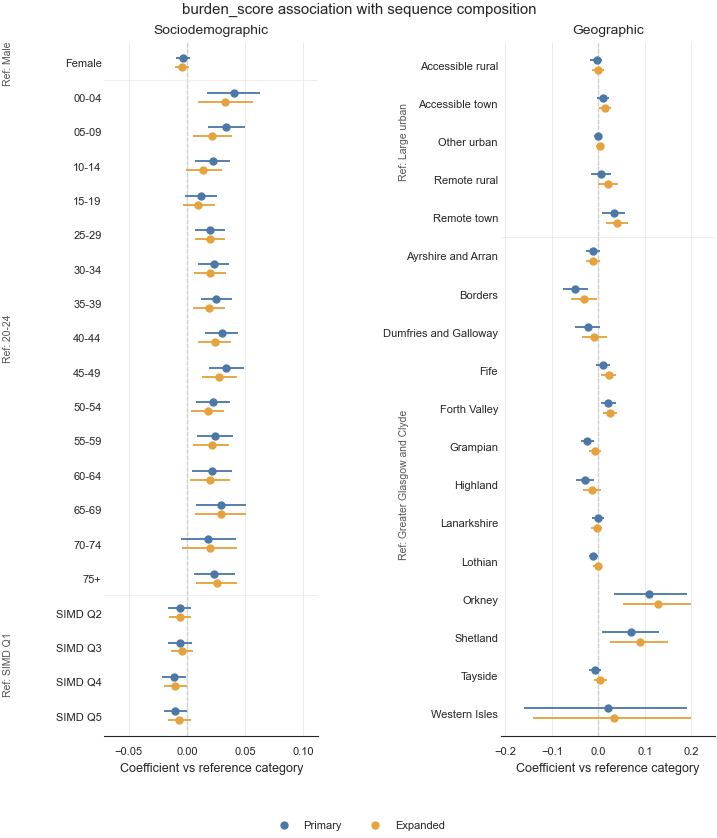

,variable,variable_label,level,reference,contrast_label,model_kind,model_set,parameter,mean,hdi95_lb,hdi95_ub,P(beta > 0 | data),P(beta < 0 | data),summary_path,contrast_id,row_id,panel,display_label,reference_display_label
38,sex,Sex,Female,Male,Sex: Female vs Male,expanded,expanded,"C(sex, Treatment(reference='Male'))[Female]",-0.00428,-0.0100,0.0021,0.087750,0.912250,/Users/ydnkka/Desktop/PhD Project/projects/sco...,sex=Female,sex=Female,sociodemographic,Female,Male
0,sex,Sex,Female,Male,Sex: Female vs Male,primary,primary,"C(sex, Treatment(reference='Male'))[Female]",-0.00323,-0.0095,0.0030,0.152625,0.847375,/Users/ydnkka/Desktop/PhD Project/projects/sco...,sex=Female,sex=Female,sociodemographic,Female,Male
39,age_band,Age band,00-04,20-24,Age band: 00-04 vs 20-24,expanded,expanded,"C(age_band, Treatment(reference='20-24'))[00-04]",0.03320,0.0098,0.0570,0.997625,0.002375,/Users/ydnkka/Desktop/PhD Project/projects/sco...,age_band=00-04,age_band=00-04,sociodemographic,00-04,20-24
1,age_band,Age band,00-04,20-24,Age band: 00-04 vs 20-24,primary,primary,"C(age_band, Treatment(reference='20-24'))[00-04]",0.04040,0.0170,0.0630,0.999375,0.000625,/Users/ydnkka/Desktop/PhD Project/projects/sco...,age_band=00-04,age_band=00-04,sociodemographic,00-04,20-24
40,age_band,Age band,05-09,20-24,Age band: 05-09 vs 20-24,expanded,expanded,"C(age_band, Treatment(reference='20-24'))[05-09]",0.02190,0.0053,0.0390,0.994500,0.005500,/Users/ydnkka/Desktop/PhD Project/projects/sco...,age_band=05-09,age_band=05-09,sociodemographic,05-09,20-24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35,dz_health_board,Health board,Shetland,Greater Glasgow and Clyde,Health board: Shetland vs Greater Glasgow and ...,primary,primary,"C(dz_health_board, Treatment(reference='Greate...",0.07040,0.0070,0.1300,0.983625,0.016375,/Users/ydnkka/Desktop/PhD Project/projects/sco...,dz_health_board=Shetland,dz_health_board=Shetland,geographic,Shetland,Greater Glasgow and Clyde
74,dz_health_board,Health board,Tayside,Greater Glasgow and Clyde,Health board: Tayside vs Greater Glasgow and C...,expanded,expanded,"C(dz_health_board, Treatment(reference='Greate...",0.00390,-0.0100,0.0180,0.716250,0.283750,/Users/ydnkka/Desktop/PhD Project/projects/sco...,dz_health_board=Tayside,dz_health_board=Tayside,geographic,Tayside,Greater Glasgow and Clyde
36,dz_health_board,Health board,Tayside,Greater Glasgow and Clyde,Health board: Tayside vs Greater Glasgow and C...,primary,primary,"C(dz_health_board, Treatment(reference='Greate...",-0.00720,-0.0210,0.0060,0.149875,0.850125,/Users/ydnkka/Desktop/PhD Project/projects/sco...,dz_health_board=Tayside,dz_health_board=Tayside,geographic,Tayside,Greater Glasgow and Clyde
75,dz_health_board,Health board,Western Isles,Greater Glasgow and Clyde,Health board: Western Isles vs Greater Glasgow...,expanded,expanded,"C(dz_health_board, Treatment(reference='Greate...",0.03400,-0.1400,0.2000,0.652125,0.347875,/Users/ydnkka/Desktop/PhD Project/projects/sco...,dz_health_board=Western Isles,dz_health_board=Western Isles,geographic,Western Isles,Greater Glasgow and Clyde


In [6]:
linear_composition_jobs = {
    "burst_score": [
        "composition/burst_score/primary",
        "composition/burst_score/expanded",
    ],
    "burden_score": [
        "composition/burden_score/primary",
        "composition/burden_score/expanded",
    ],
}

for outcome, required in linear_composition_jobs.items():
    if has_summaries(LINEAR_RESULT_DIR, required):
        linear_composition = plot_composition_primary_expanded_forest(
            LINEAR_RESULT_DIR,
            family="linear",
            outcome=outcome,
            title=f"{outcome} association with sequence composition",
        )
        plot_outputs[f"linear_composition_{outcome}"] = {
            "result": linear_composition,
            "files": save_forest(
                linear_composition.fig,
                f"linear_composition_{outcome}_primary_expanded_forest",
            ),
        }
        display(linear_composition.fig)
        display(linear_composition.plot_data)
    else:
        missing = [
            rel
            for rel in required
            if not (LINEAR_RESULT_DIR / rel / "summary.csv").exists()
        ]
        print(f"Skipping linear composition forest for {outcome}; missing summaries:")
        print(
            "\n".join(str(LINEAR_RESULT_DIR / rel / "summary.csv") for rel in missing)
        )

In [7]:
plot_outputs

{'logistic_mixing': {'result': ForestPlotResult(fig=<Figure size 720x340 with 2 Axes>, axes=array([<Axes: title={'center': 'Observed entropy'}, xlabel='OR per 0.1-bit increase'>,
         <Axes: title={'center': 'Null-standardised entropy'}, xlabel='OR per 1 SD increase'>],
        dtype=object), plot_data=       scale model_kind          model_set               feature  \
  0   observed    primary   observed_primary           sex_entropy   
  5   observed   expanded  observed_expanded           sex_entropy   
  1   observed    primary   observed_primary           age_entropy   
  6   observed   expanded  observed_expanded           age_entropy   
  2   observed    primary   observed_primary          simd_entropy   
  7   observed   expanded  observed_expanded          simd_entropy   
  3   observed    primary   observed_primary   urban_rural_entropy   
  8   observed   expanded  observed_expanded   urban_rural_entropy   
  4   observed    primary   observed_primary  health_board_entro